In [349]:
%load_ext autoreload
%autoreload 2
%env CUDA_VISIBLE_DEVICES=1

import numpy as np
import sys
import os
import matplotlib.pyplot as plt
import vis_utils

from utils.utils import get_path
from utils.io_utils import load_multiple_res
from utils.toydata_utils import get_toy_data
from utils.fig_utils import dataset_to_print, plot_dgm_loops, dist_to_print, plot_edges_on_scatter
from utils.pd_utils import sort_cycle

from vis_utils.loaders import load_dataset
from vis_utils.plot import plot_scatter
from vis_utils.utils import load_dict, save_dict
from vis_utils.tsne_wrapper import TSNEwrapper
from vis_utils.total_variation import total_variation_matrix, complete_linkage_tri, tune_tri_threshold
from openTSNE.affinity import Affinities

import umap
from ripser import Rips
from ripser.ripser import get_greedy_perm

from mpl_toolkits.axes_grid1 import make_axes_locatable

from matplotlib import collections  as mc
from matplotlib.colors import Normalize
import matplotlib.cm

from openTSNE.nearest_neighbors import PrecomputedNeighbors
from openTSNE.affinity import PerplexityBasedNN

from vis_utils.utils import kNN_graph, kNN_dists
from scipy.spatial.distance import pdist, squareform
import glasbey
import scipy.sparse
import networkx as nx

from sklearn.decomposition import PCA
from sklearn.manifold import MDS

from persim import plot_diagrams
from utils.pd_utils import get_life_times
import pandas as pd
from collections import Counter

from sklearn.decomposition import PCA
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.image as mpimg
import community as community_louvain
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist

from itertools import chain

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
env: CUDA_VISIBLE_DEVICES=1


# load distribution

In [351]:
style_file = "utils.style"
plt.style.use(style_file)

distances = {
    # "euclidean": [{}],
    "diffusion": [
        {"k": 15, "t": 8, "kernel": "sknn", "include_self": False},
        {"k": 100, "t": 8, "kernel": "sknn", "include_self": False},
        {"k": 15, "t": 64, "kernel": "sknn", "include_self": False},
        {"k": 100, "t": 64, "kernel": "sknn", "include_self": False},
    ],
    "eff_res": [
        {"corrected": True, "weighted": False, "k": 15, "disconnect": True},
        {"corrected": True, "weighted": False, "k": 100, "disconnect": True},
    ],
}

In [ ]:

root_path = get_path("data")
tasic_orange_enm= np.load(os.path.join(root_path, "embd_n_mask", "embd_after_procrustes", "embd_tasic_orange.npy"))
smart_orange_enm= np.load(os.path.join(root_path, "embd_n_mask", "embd_after_procrustes", "embd_smart_orange.npy"))
x10_orange_enm= np.load(os.path.join(root_path, "embd_n_mask", "embd_after_procrustes", "embd_10x_orange_10k.npy"))


In [356]:
dist_tasic_orange = load_dict(os.path.join(root_path,"final_dist_bottleneck_max", "dist_tasic_orange.pkl"))
dist_smart_orange = load_dict(os.path.join(root_path,"final_dist_bottleneck_max", "dist_smart_orange.pkl"))
dist_10x_orange = load_dict(os.path.join(root_path,"final_dist_bottleneck_max", "dist_10x_orange.pkl"))


In [ ]:
data_tri = [f"{i}" for i, dataset in enumerate([dist_tasic_orange["idx"], dist_smart_orange["idx"], dist_10x_orange["idx"]]) for j in dataset]
idx_tri = [f"{j}" for i, dataset in enumerate([dist_tasic_orange["idx"], dist_smart_orange["idx"], dist_10x_orange["idx"]]) for j in dataset]

In [ ]:
density_tri = np.vstack([dist_tasic_orange["density"], dist_smart_orange["density"], dist_10x_orange["density"]])

# tri orange

In [368]:
tri_mat = total_variation_matrix(density_tri, density_tri)

In [370]:
trim_list_of_communities, trim_data, trim_idx  = complete_linkage_tri(tri_mat, threshold = 0.7)

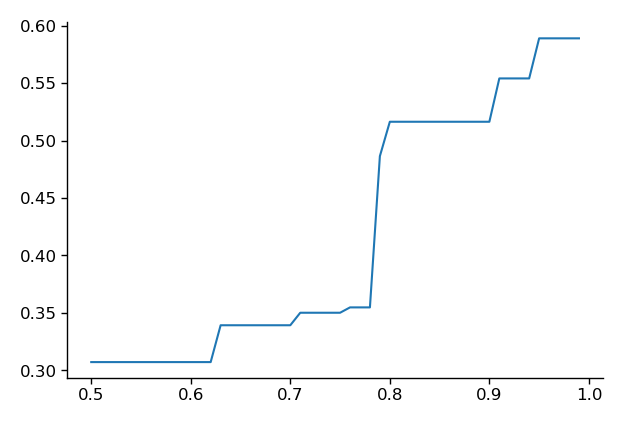

In [ ]:
plt.figure(figsize = (3,2))
plt.plot(np.arange(0.5, 1, 0.01), ave_tv)


In [ ]:
tri_mat, ave_tv, n_tv =tune_tri_threshold(tri_mat)

In [ ]:
print(trim_data)

[['0', '0', '1', '2'], ['0', '0', '0', '0', '0', '0', '1', '2', '2', '2', '2', '2', '2'], ['0', '0', '0', '0', '1', '1', '2', '2', '2', '2'], [['0'], ['0'], ['1', '2'], ['0', '0', '1', '1'], ['1', '1', '1', '1', '1', '1', '1', '2'], ['1', '1', '1', '2'], ['1', '1', '1'], ['1', '1', '1', '1', '2', '2', '2'], ['0', '0', '0', '0', '0']]]


In [ ]:
print(trim_idx)

[['03', '13', '16', '11'], ['02', '05', '12', '30', '41', '50', '30', '01', '13', '20', '30', '40', '52'], ['00', '10', '40', '52', '18', '55', '00', '10', '21', '51'], [['06'], ['14'], ['51', '54'], ['04', '15', '17', '56'], ['11', '12', '40', '41', '50', '52', '53', '53'], ['10', '13', '31', '12'], ['00', '19', '42'], ['14', '15', '54', '57', '14', '15', '50'], ['01', '11', '20', '42', '51']]]


Done with tasic_orange None diffusion_k_15_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with tasic_orange None diffusion_k_100_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with tasic_orange None diffusion_k_15_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with tasic_orange None diffusion_k_100_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with tasic_orange None eff_res_corrected_True_weighted_False_k_15_disconnect_True n_outliers=0, perturbation=None
Done with tasic_orange None eff_res_corrected_True_weighted_False_k_100_disconnect_True n_outliers=0, perturbation=None
Done with yao_smart_orange None diffusion_k_15_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_smart_orange None diffusion_k_100_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_smart_orange None diffusion_k_15_t_64_kernel_sknn_include_self_False n_out

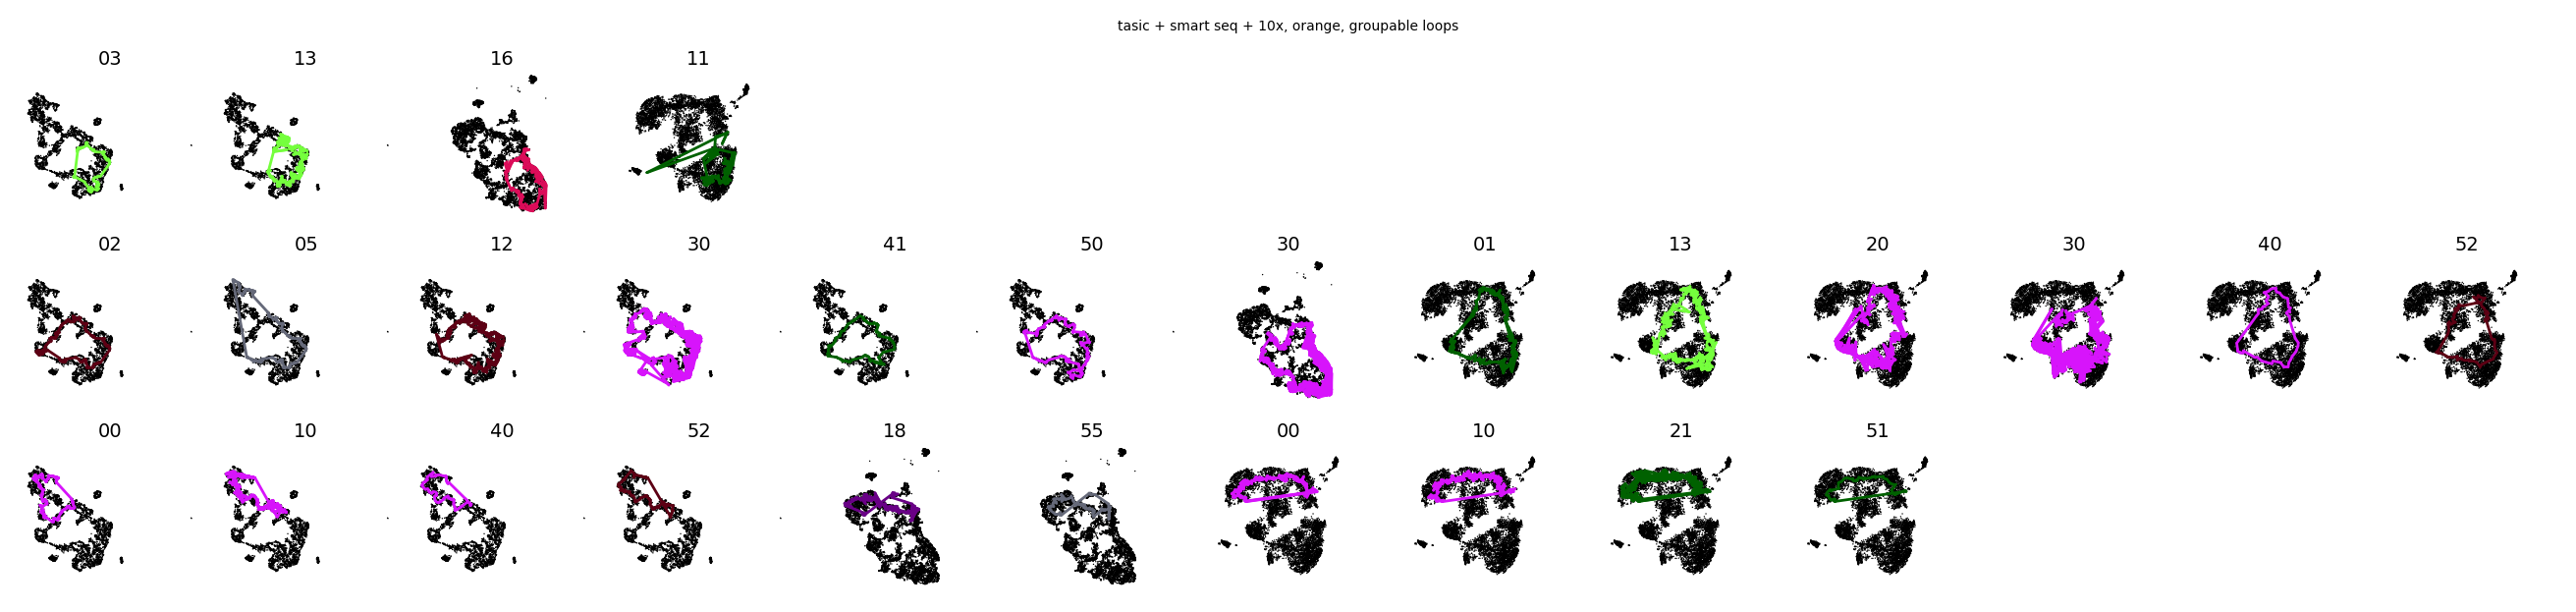

In [392]:
pic_tri_pigeonhole_loops(trim_list_of_communities, trim_data, trim_idx, "tasic_orange", "yao_smart_orange", "yao_10x_male_orange_0_10k", "orange", save = True) #, saveas = "orange_fig_tri.png"

Done with tasic_orange None diffusion_k_15_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with tasic_orange None diffusion_k_100_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with tasic_orange None diffusion_k_15_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with tasic_orange None diffusion_k_100_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with tasic_orange None eff_res_corrected_True_weighted_False_k_15_disconnect_True n_outliers=0, perturbation=None
Done with tasic_orange None eff_res_corrected_True_weighted_False_k_100_disconnect_True n_outliers=0, perturbation=None
Done with yao_smart_orange None diffusion_k_15_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_smart_orange None diffusion_k_100_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_smart_orange None diffusion_k_15_t_64_kernel_sknn_include_self_False n_out

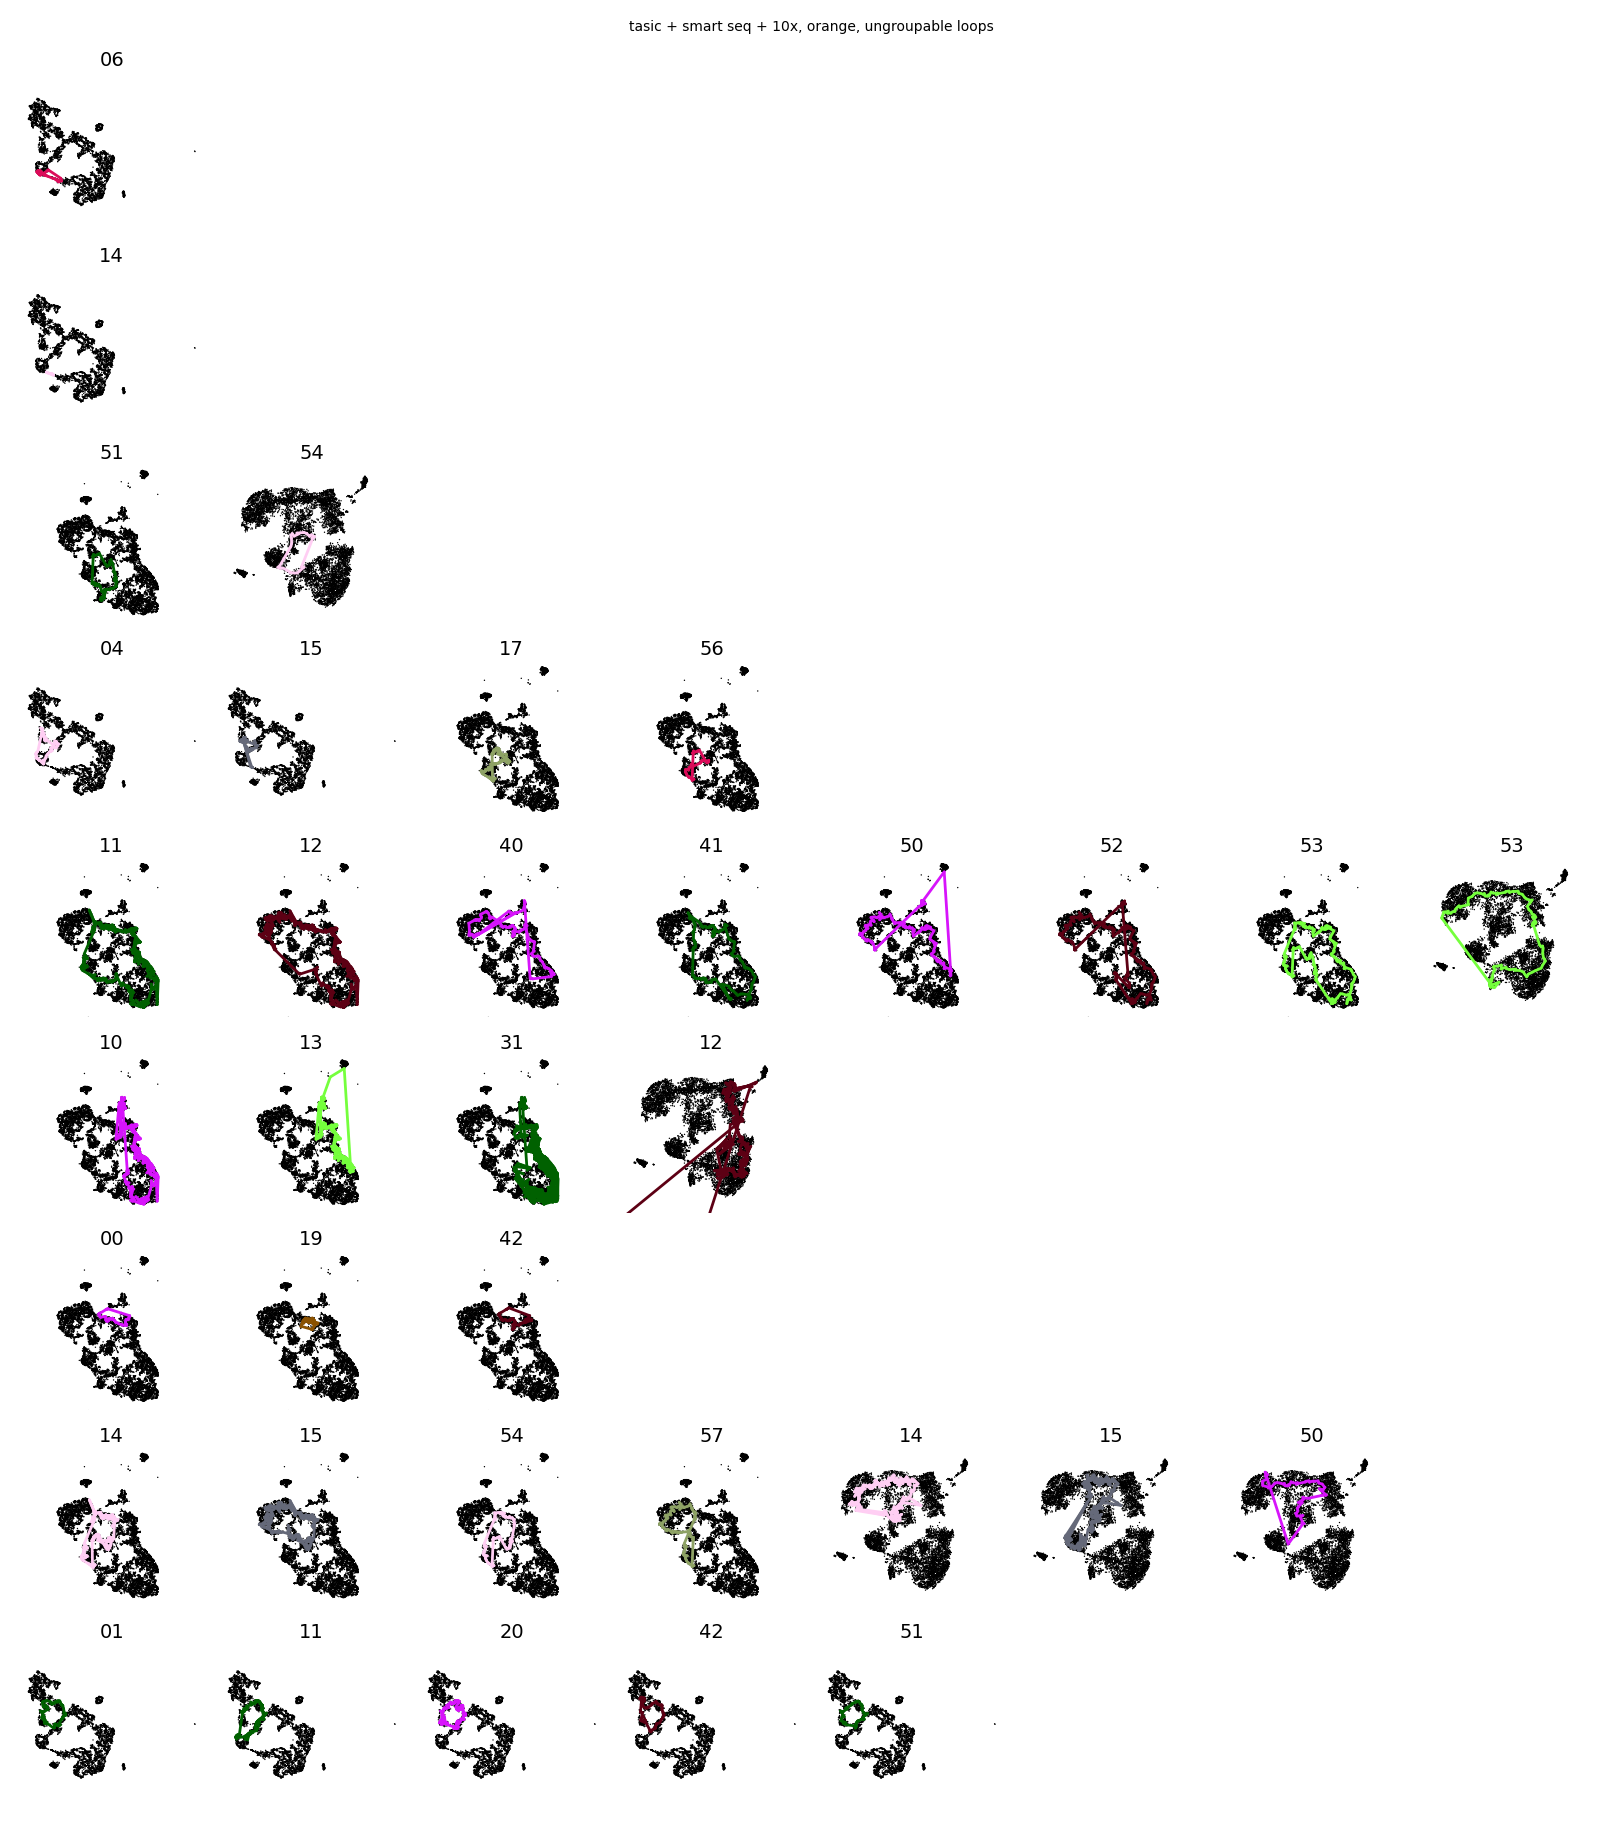

In [ ]:
pic_tri_pigeonhole_loops(trim_list_of_communities, trim_data, trim_idx, "tasic_orange", "yao_smart_orange", "yao_10x_male_orange_0_10k", "orange", groupable = False, save = True) #, saveas = "orange_fig_tri.png"